# 1- Problem Definition

#### Problem Definition

Customer churn occurs when a customer stops using a company's services. For telecommunications companies, customer churn can result in lost revenue and increased costs associated with acquiring new customers. Being able to identify customers who may be at risk of leaving can help companies better understand customer behavior and develop strategies to improve customer retention.

The purpose of this project is to develop a machine-learning model that predicts whether a telecommunications customer will churn based on customer characteristics and service usage information.

#### Prediction Question

**Can customer characteristics and service usage patterns be used to predict whether a telecommunications customer will churn?**

#### Target Variable

The target variable is `Churn`, which identifies whether a customer churned:

- `No` = Customer did not churn
- `Yes` = Customer churned

For machine-learning analysis, the target will be converted to:

- `0` = No churn
- `1` = Churn

#### Type of Machine-Learning Problem

This is a **binary classification problem** because the model predicts one of two possible outcomes: churn or no churn.

A model that can identify customers at risk of churn may be useful to telecommunications companies when developing customer-retention strategies.

# 2. Background and Context

#### Background and Context

Customer churn is an important issue in the telecommunications industry because customers can often choose among multiple service providers. Understanding the characteristics associated with churn can help telecommunications companies identify patterns in customer behavior and potentially improve customer-retention efforts.

Machine learning provides methods for examining customer information and identifying patterns that may help predict whether a customer is likely to leave. Customer characteristics, service usage, account history, and other service-related variables can potentially contribute to churn
prediction.

In this project, machine-learning classification methods will be used to examine telecommunications customer data and predict customer churn.

#### Supporting Research

Three credible or peer-reviewed sources related to telecommunications customer churn and machine-learning prediction will be used to provide additional context for this analysis.

Ahmad, A. K., Jafar, A., & Aljoumaa, K. (2019). Customer churn prediction in telecom using machine learning in big data platform. *Journal of Big Data, 6*, Article 28. https://doi.org/10.1186/s40537-019-0191-6

Huang, B., Kechadi, M. T., & Buckley, B. (2012). Customer churn prediction in telecommunications. *Expert Systems with Applications, 39*(1), 1414–1425. https://doi.org/10.1016/j.eswa.2011.08.024

Sikri, A., Jameel, R., Idrees, S. M., & Kaur, H. (2024). Enhancing customer retention in telecom industry with machine learning driven churn prediction. *Scientific Reports, 14*, Article 13097. https://doi.org/10.1038/s41598-024-63750-0

# 3. Data Description

#### 3.1 Import libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#### 3.2 Load the dataset

In [4]:
# Load dataset
telco_churn_raw = pd.read_csv('telco-customer-churn.csv')
telco_churn_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ServiceCount,InternetScore,AvgServiceUsageScore,Churn
0,7590-VHVEG,Female,0,Yes,No,1,0,No phone service,DSL,0,...,0,Month-to-month,Yes,Electronic check,29.85,29.85,1,20,6.651318,No
1,5575-GNVDE,Male,0,No,No,34,1,No,DSL,1,...,0,One year,No,Mailed check,56.95,1889.5,3,20,12.794164,No
2,3668-QPYBK,Male,0,No,No,2,1,No,DSL,1,...,0,Month-to-month,Yes,Mailed check,53.85,108.15,3,20,15.077513,Yes
3,7795-CFOCW,Male,0,No,No,45,0,No phone service,DSL,1,...,0,One year,No,Bank transfer (automatic),42.30,1840.75,3,20,17.299583,No
4,9237-HQITU,Female,0,No,No,2,1,No,Fiber optic,0,...,0,Month-to-month,Yes,Electronic check,70.70,151.65,1,40,18.222739,Yes


In [9]:
# print dataset shape
print("Dataset shape:", telco_churn_raw.shape)
# print the information concerning the dataset
telco_churn_raw.info()

Dataset shape: (7043, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   gender                7043 non-null   object 
 2   SeniorCitizen         7043 non-null   int64  
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   tenure                7043 non-null   int64  
 6   PhoneService          7043 non-null   int64  
 7   MultipleLines         7043 non-null   object 
 8   InternetService       7043 non-null   object 
 9   OnlineSecurity        7043 non-null   int64  
 10  OnlineBackup          7043 non-null   int64  
 11  DeviceProtection      7043 non-null   int64  
 12  TechSupport           7043 non-null   int64  
 13  StreamingTV           7043 non-null   int64  
 14  StreamingMovies       7043 non-null   int64  


#### Data Description

The dataset used in this project contains information abouttelecommunications customers and whether they churned. Each row represents one telecommunications customer. The dataset contains **7,043 customer observations and 24 variables**. The variables include customer characteristics, account information, service information, charges, service usage measures, and the churn outcome.

The target variable is `Churn`, which indicates whether the customer left the telecommunications company.

Potential predictor variables include:

- `tenure`
- `SeniorCitizen`
- `ServiceCount`
- `InternetScore`
- `AvgServiceUsageScore`
- `MonthlyCharges`
- `Contract`
- other customer and service characteristics

The dataset will be examined for missing values, unusual observations, and other characteristics before the machine-learning models are developed.

# 4. Data Understanding and Exploration

#### 4.1. Check duplicates

In [10]:
telco_churn_raw.duplicated().sum()

np.int64(0)

#### 4.2. Check missing values

In [11]:
telco_church_raw.isnull().sum()

customerID                0
gender                    0
SeniorCitizen             0
Partner                   0
Dependents                0
tenure                    0
PhoneService              0
MultipleLines             0
InternetService           0
OnlineSecurity            0
OnlineBackup              0
DeviceProtection          0
TechSupport               0
StreamingTV               0
StreamingMovies           0
Contract                  0
PaperlessBilling          0
PaymentMethod             0
MonthlyCharges          422
TotalCharges              0
ServiceCount              0
InternetScore             0
AvgServiceUsageScore    619
Churn                     0
dtype: int64

##### Missing Values and Duplicates
The dataset was examined for duplicate observations and missing values.The missing-value analysis showed that `MonthlyCharges` contains 422
missing values and `AvgServiceUsageScore` contains 619 missing values. These missing values must be addressed before training the machine-learning models.

#### 4.3. Look at the target variable

In [15]:
telco_church_raw["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
# in term of pourcentage
telco_church_raw["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### 4.4. Target visualization

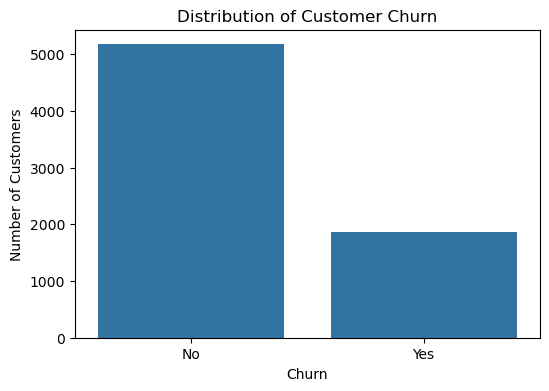

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=telco_churn_raw, x="Churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

#### Target Variable Distribution
The dataset contains 7,043 customers. Of these customers, 5,174 (73.46%) did not churn, while 1,869 (26.54%) churned. This shows that the target variable is imbalanced because the majority of customers belong to the non-churn group. Because of this imbalance, accuracy alone may not provide a complete picture of model performance. Precision, recall, and F1-score are also used to evaluate how well the models identify customers who actually churn.

#### 4.5. Summary statistics

In [21]:
telco_churn_raw.describe()

,SeniorCitizen,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,ServiceCount,InternetScore,AvgServiceUsageScore
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6621.000000,7043.000000,7043.000000,6424.000000
mean,0.162147,32.371149,0.903166,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,64.807174,2.941076,24.458327,16.692560
std,0.368612,24.559481,0.295752,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,30.110964,1.843899,15.577533,9.385134
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,1.000000,20.000000,9.187367
50%,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.350000,3.000000,20.000000,17.647544
75%,0.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.900000,4.000000,40.000000,23.856830
max,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,7.000000,40.000000,42.896068


#### Interpretation of Summary Statistics
The summary statistics provide an overview of the numerical variablesused in the analysis. Customer tenure ranges from 0 to 72, with an average of approximately 32.37. Monthly charges average approximately $64.81 and range from $18.25 to $118.75. Customers have an average ServiceCount of approximately 2.94, while the average service usage score is approximately 16.69. These results show that there is considerable variation in customer account history, monthly charges, and service usage, which may provide useful information
for predicting customer churn.

#### 4.6. Tenure vs churn

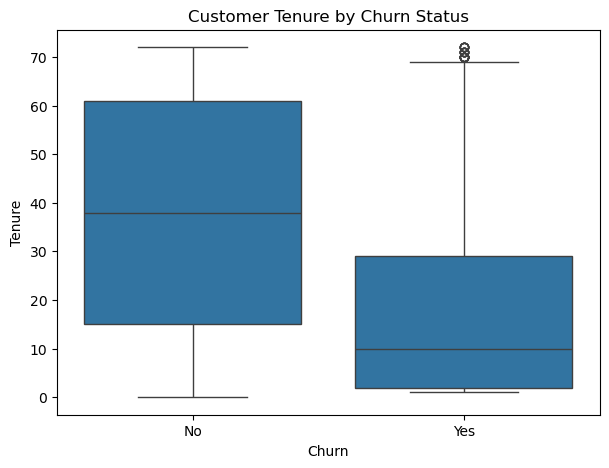

In [22]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=telco_churn_raw, x="Churn", y="tenure")
plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

The tenure visualization helps examine whether customers who churn have different account histories from customers who remain with the
company. Differences between the two groups may indicate that tenure could be useful as a predictor in the classification models.

#### 4.7. Monthly charges vs churn

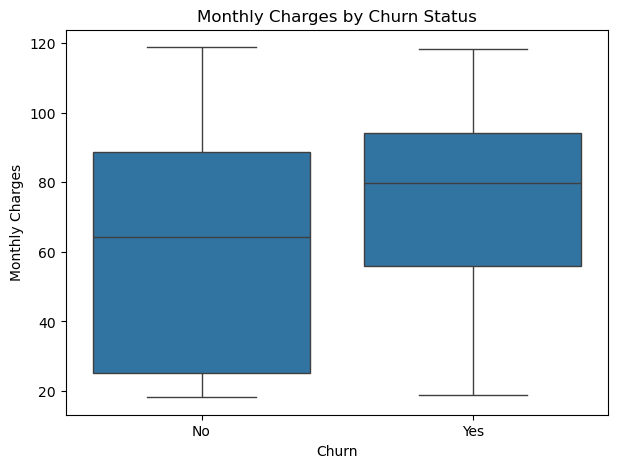

In [46]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=telco_churn_raw,x="Churn",y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

The monthly-charge visualization compares the distribution of customer charges between customers who churned and customers who did not churn.
This helps determine whether monthly charges may contain useful information for predicting churn.

### 4.8. relationship between AvgServiceUsageScore and MonthlyCharges

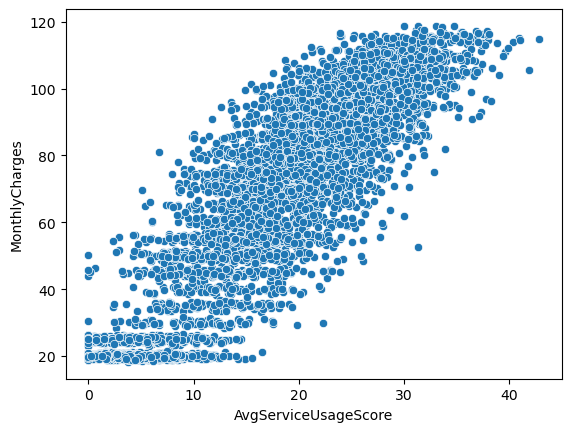

In [47]:
sns.scatterplot(data = telco_church, x = 'AvgServiceUsageScore', y='MonthlyCharges')
plt.show();

##### Interpretation of AvgServiceUsageScore and MonthlyCharges

The scatter plot compares customers' average service usage scores with their monthly charges. The points show considerable variation, indicating that customers with similar service usage scores can have different monthly charges.

The plot does not show a simple one-to-one relationship between the two variables. However, it is useful for understanding how these two customer characteristics are distributed before they are included in the machine-learning models. This exploration supports examining both variables as potential predictors rather than assuming that one variable can substitute for the other.

#### 4.9relationship between InternService and Churn

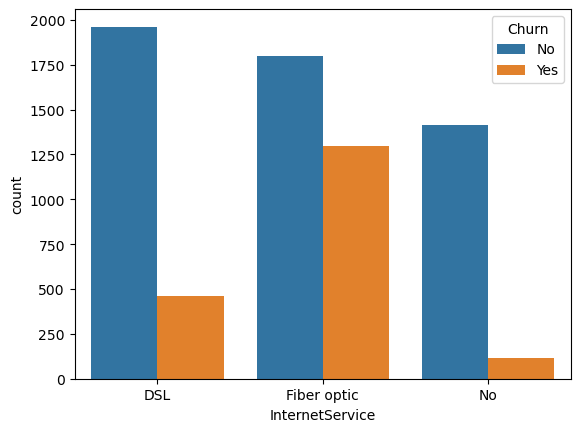

In [59]:
# side-by-side barplot
sns.countplot(data=telco_church, x='InternetService',hue='Churn')
plt.show();

##### Interpretation of Internet Service and Churn

The bar chart compares churn outcomes across the different InternetService categories. The distribution of churn is not the same across all internet-service groups, suggesting that the type of internet service may be related to customer churn behavior.

The graph provides evidence that service-related characteristics may contain useful information for understanding churn. However, the visualization shows an association only and does not demonstrate that a particular type of internet service causes customers to churn.


# 5. Data Preparation and Feature Selection


Before developing the machine-learning models, the data were prepared for analysis. A copy of the original dataset was created so that the raw data would remain unchanged.

The `Churn` target variable was converted from Yes/No values to binary values, where 1 represents churn and 0 represents no churn.

Selected numerical customer and service variables were used as predictors. Missing numerical values were handled using median imputation because the median is less sensitive to extreme values than the mean.

The data were then separated into training and testing sets. The training data are used to develop the models, while the testing data
are reserved for evaluating how well the models perform on observations they did not see during training.

In [27]:
# Make a copy of the data to fix and clean ( this help just case I make a bad change)
telco_churn = telco_churn_raw.copy()

### 5.1. Convert target

In [28]:
telco_churn["Churn"] = telco_churn["Churn"].map({
    "Yes": 1,
    "No": 0
})

### 5.2. Select features

In [30]:
features = [
    "tenure",
    "SeniorCitizen",
    "ServiceCount",
    "InternetScore",
    "AvgServiceUsageScore",
    "MonthlyCharges"
]

X = telco_churn[features].copy()
y = telco_churn["Churn"]

### 5.3 . Split the data into training and Test

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=2025,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 6)
Testing set: (1409, 6)


#### Interpretation of Training and Testing Data
The dataset was divided into training and testing sets using an 80/20 split. The training set contains 5,634 customers and is used to train
the machine-learning models. The testing set contains 1,409 customers and is used to evaluate the models on data they did not see during
training.
A stratified split was used to maintain approximately the same proportion of churn and non-churn customers in both datasets.

### 5.4. Handle missing values

In [32]:
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Training missing values:")
print(X_train.isnull().sum())

print("\nTesting missing values:")
print(X_test.isnull().sum())

Training missing values:
tenure                  0
SeniorCitizen           0
ServiceCount            0
InternetScore           0
AvgServiceUsageScore    0
MonthlyCharges          0
dtype: int64

Testing missing values:
tenure                  0
SeniorCitizen           0
ServiceCount            0
InternetScore           0
AvgServiceUsageScore    0
MonthlyCharges          0
dtype: int64


#### Interpretation of Missing-Value Treatment
After median imputation, none of the six selected predictor variables contained missing values in either the training or testing datasets.
The medians were calculated using only the training data and then applied to both datasets. This prevents information from the testing
data from influencing the preprocessing of the training data and helps reduce the risk of data leakage.

# 6. Baseline and Model Development

Before training the machine-learning models, a baseline classifier was
created.The baseline predicts the most common class in the training data. This provides a simple benchmark that the trained machine-learning models
should improve upon.

#### 6.1. Baseline model

In [35]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.7345635202271115


#### 6.2 Logistic Regression

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
log_model = LogisticRegression(random_state=2025,max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

### Logistic Regression

Logistic Regression was selected as the first machine-learning model because it is commonly used for binary classification problems. The numerical predictor variables were standardized before training the Logistic Regression model because the predictors are measured on different scales. The scaler was fitted only on the training data and then applied to the testing data to help prevent data leakage.

#### 6.3 Random Forest

In [40]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=2025)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

### Random Forest

Random Forest was selected as the second classification model. Random Forest combines multiple decision trees and can capture nonlinear relationships and interactions between predictor variables.
Unlike Logistic Regression, Random Forest does not require numerical features to be standardized, so the model was trained using the unscaled predictor variables. Using Logistic Regression and Random Forest allows the project to compare two different approaches to predicting customer churn.

# 7. Model Evaluation and Selection

In [41]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, log_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, log_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, log_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.734564,0.000000,0.000000,0.000000
1,Logistic Regression,0.800568,0.678161,0.473262,0.557480
2,Random Forest,0.768630,0.585714,0.438503,0.501529


### Interpretation of Model Performance

The baseline model achieved an accuracy of 73.46%. However, its precision, recall, and F1-score were all zero because the baseline
simply predicted the majority class and did not identify customers who churned. This demonstrates why accuracy alone is not sufficient for
evaluating this dataset.

Logistic Regression achieved an accuracy of 80.06%, precision of 67.82%, recall of 47.33%, and an F1-score of 55.75%. This means that
about 67.82% of customers predicted to churn actually churned, while the model identified approximately 47.33% of all customers who actually
churned.

Random Forest achieved an accuracy of 76.86%, precision of 58.57%, recall of 43.85%, and an F1-score of 50.15%.

Based on these results, Logistic Regression was selected as the final model because it performed better than Random Forest on all four evaluation metrics used in this analysis. It also improved upon the baseline model while demonstrating an ability to identify customers
from the churn class.

Although Logistic Regression performed better overall, its recall of 47.33% indicates an important limitation. The model failed to identify
more than half of the customers who actually churned. Therefore, there is still substantial room to improve the model's ability to identify
customers at risk of leaving.

## 7. Model Evaluation and Selection

The models were evaluated using accuracy, precision, recall, and
F1-score.

- **Accuracy** measures the proportion of all predictions that were correct.
- **Precision** measures how often customers predicted to churn actually churned.
- **Recall** measures how many of the actual churn customers were correctly identified.
- **F1-score** balances precision and recall into a single measure.

Because the churn classes are imbalanced, the evaluation does not rely only on accuracy. Recall and F1-score are especially useful for
understanding how effectively the models identify customers who actually churn.

# 8. Model Interpretation and Insights

#### 8.1 Confusion matrices

##### 8.1.1. Logistic Regression

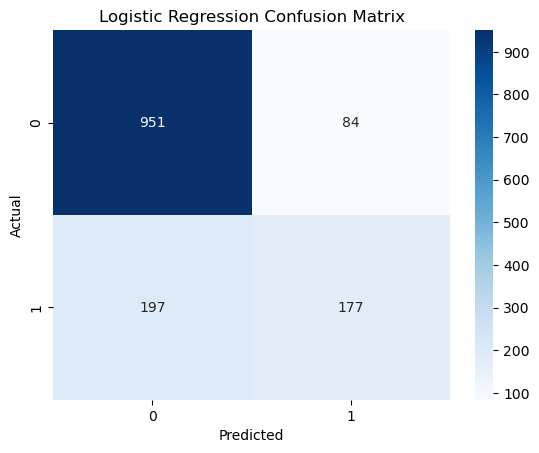

In [42]:
log_cm = confusion_matrix(y_test, log_pred)

sns.heatmap(
    log_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##### 8.1.2. Random Forest

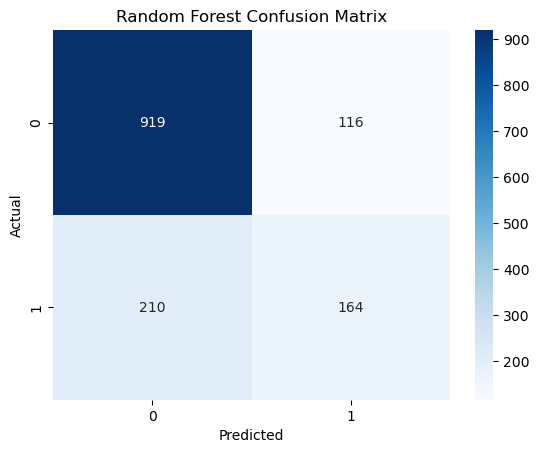

In [43]:
rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##### Interpretation of Confusion Matrices
The confusion matrices provide a closer look at the types of predictions made by the Logistic Regression and Random Forest models.

The Logistic Regression model correctly predicted 951 customers who did not churn and 177 customers who did churn. However, it incorrectly predicted 84 non-churn customers as churn customers and failed to identify 197 customers who actually churned.

The Random Forest model correctly predicted 919 customers who did not churn and 164 customers who did churn. It incorrectly predicted 116
non-churn customers as churn customers and failed to identify 210 customers who actually churned.

Comparing the two models, Logistic Regression produced fewer false positives and fewer false negatives than Random Forest. It also correctly
identified more customers who actually churned. These results support the selection of Logistic Regression as the better-performing model in this
analysis.

False negatives are particularly important in this project because they represent customers who actually churned but were predicted not to churn.
If the model were used to support customer-retention efforts, these customers could be missed. Although Logistic Regression performed better
than Random Forest, the number of false negatives shows that the model still has room for improvement.

#### 8.2. Random Forest feature importance

##### 8.2.1. Table of the feature

In [54]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,tenure,0.299406
5,MonthlyCharges,0.280172
4,AvgServiceUsageScore,0.263382
3,InternetScore,0.075278
2,ServiceCount,0.062356
1,SeniorCitizen,0.019406


##### 8.2.2.  Plot Random Forest features

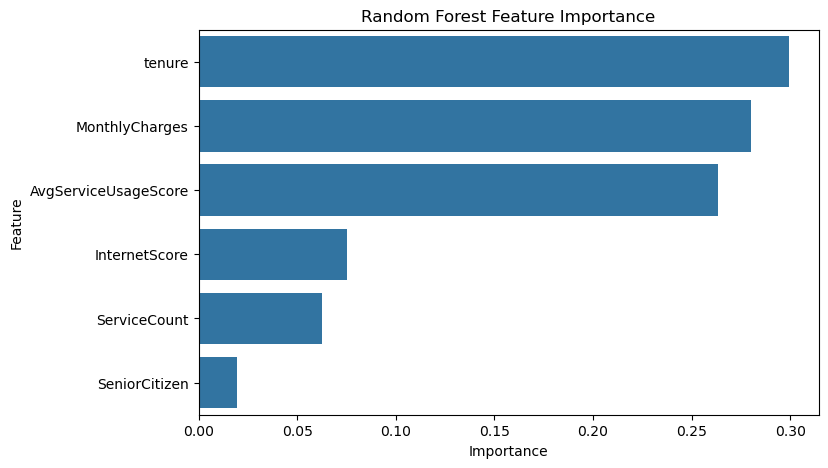

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

##### Interpretation of Feature Importance
The Random Forest feature-importance results show that `tenure` was the most influential predictor in this model, with an importance of approximately 29.94%. `MonthlyCharges` was the second most influential feature at approximately 28.02%, followed closely by
`AvgServiceUsageScore` at approximately 26.34%.

`InternetScore` and `ServiceCount` contributed less to the model, while `SeniorCitizen` had the lowest feature importance among the selected
predictors.

These results suggest that customer tenure, monthly charges, and average service usage provided the Random Forest model with the most useful information for making churn predictions. However, feature importance represents predictive usefulness within this model and does not mean that these variables cause customers to churn.

### 8.3. Logistic Regression Coefficients

##### 8.3.1. Logistic regression coefficients table

In [57]:
log_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
})

log_coefficients = log_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

log_coefficients

,Feature,Coefficient
3,InternetScore,0.770468
5,MonthlyCharges,0.375323
1,SeniorCitizen,0.174274
4,AvgServiceUsageScore,0.022771
2,ServiceCount,-0.295840
0,tenure,-1.054920


##### 8.3.2. Plot Logistic regression coefficient

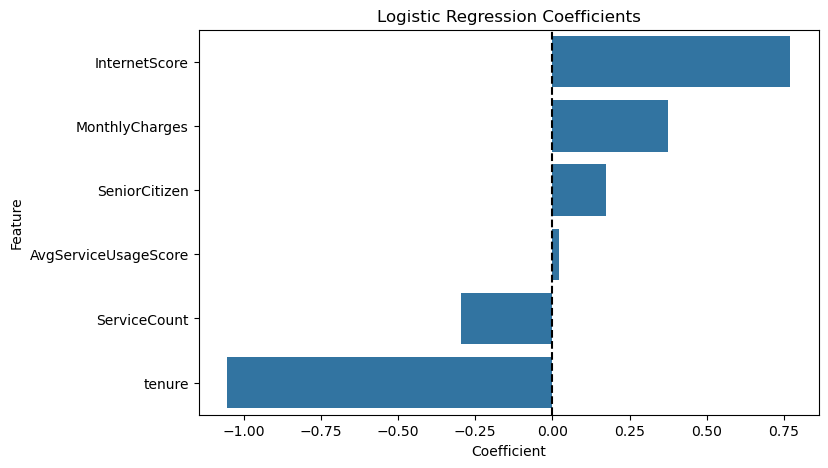

In [58]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=log_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.axvline(x=0, color="black", linestyle="--")

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

##### Interpretation of Logistic Regression Coefficients

The Logistic Regression coefficients provide information about how each feature is associated with the model's prediction of customer churn, while holding the other included features constant.

`InternetScore` has the largest positive coefficient (0.770), indicating that higher InternetScore values are associated with a higher predicted
likelihood of churn. `MonthlyCharges` also has a positive coefficient (0.375), suggesting that higher monthly charges are associated with a higher predicted likelihood of churn.

`SeniorCitizen` has a positive coefficient (0.174), while `AvgServiceUsageScore` has a small positive coefficient (0.023).

In contrast, `tenure` has the largest negative coefficient (-1.055). This indicates that customers with longer tenure are associated with a
lower predicted likelihood of churn. `ServiceCount` also has a negative coefficient (-0.296), indicating that customers with more services are associated with a lower predicted likelihood of churn.

Because the numerical predictors were standardized before fitting the Logistic Regression model, the coefficient magnitudes can be compared
more meaningfully across the included features. Among these predictors, tenure shows the strongest relationship with the model's churn
prediction.These relationships are predictive associations and should not be interpreted as evidence that any of these features causes customer churn.

# 9. Limitations, Ethics, and Reflection


This analysis has several limitations. The machine-learning models are based only on the variables available in the dataset, so other factors
that may influence customer churn may not be represented.

The target variable is also imbalanced, with fewer churn customers than non-churn customers. This can affect how models learn to identify the
smaller churn class and is one reason multiple evaluation metrics were used.

Prediction errors also have practical consequences. A false negative occurs when the model predicts that a customer will remain when the customer actually churns. In a real telecommunications environment, this could cause the company to miss an opportunity to engage with a
customer who may be considering leaving.

A false positive occurs when the model predicts churn for a customer who would actually remain. This could result in unnecessary retention
efforts or resources being directed toward that customer.

The model should therefore be viewed as a decision-support tool rather than a system that should make customer decisions automatically.
Predictions should be interpreted alongside additional customer and business information.

The results identify predictive relationships in this dataset and do not establish that any feature causes customer churn.

Future work could examine additional customer characteristics, perform hyperparameter tuning, compare additional classification algorithms,
and investigate methods for addressing class imbalance.

# 10. Code and Transparency

The complete Python code used for data preparation, exploratory data analysis,machine-learning model development, evaluation, and interpretation is available in my GitHub repository.

#### GitHub Repository

[View Data Science Portfolio Repository](https://github.com/gaguegue-glitch/data-science-portfolio)

#### Portfolio Website

[View My Data Science Portfolio](https://gaguegue-glitch.github.io/data-science-portfolio/)

#### Jupyter Notebook

[View Project 2 Jupyter Notebook](https://github.com/gaguegue-glitch/data-science-portfolio/blob/main/Project2.ipynb)

#### Data Source

The dataset used in this project is based on the IBM Telco Customer Churn dataset. The original dataset contains information about 7,043 telecommunications customers, including customer demographics, services, account information, monthly charges, and churn status.

The version used in this project also contains additional derived service-usage features used for machine-learning analysis.

[IBM Telco Customer Churn Dataset - Kaggle](https://www.kaggle.com/blastchar telco-customer-churn)

#### AI Usage Disclosure

OpenAI ChatGPT (GPT-5.6 Sol) was used as a support tool during this project. It was used to help organize the project workflow, troubleshoot and explain Python code, explain machine-learning concepts and evaluation metrics, and improve the clarity and organization of written interpretations.

The machine-learning code was executed in the Jupyter Notebook, and the resulting outputs, visualizations, and model-performance results were reviewed before being included in the final project.

#### References

Ahmad, A. K., Jafar, A., & Aljoumaa, K. (2019). Customer churn prediction in telecom using machine learning in big data platform. *Journal of Big Data, 6*, Article 28. https://doi.org/10.1186/s40537-019-0191-6

Huang, B., Kechadi, M. T., & Buckley, B. (2012). Customer churn prediction in telecommunications. *Expert Systems with Applications, 39*(1), 1414–1425. https://doi.org/10.1016/j.eswa.2011.08.024

Sikri, A., Jameel, R., Idrees, S. M., & Kaur, H. (2024). Enhancing customer retention in telecom industry with machine learning driven churn prediction. *Scientific Reports, 14*, Article 13097. https://doi.org/10.1038/s41598-024-63750-0